# Figure 3 â€” SMI Development Over Days

**Panel A** â€” Median SMI per layer per day (mean Â± SEM across animals)

In [330]:
import os, re, glob
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
import h5py
import matplotlib as mpl

# â”€â”€ Font â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
mpl.rcParams['font.family']      = 'Arial'
mpl.rcParams['font.weight']      = 'normal'
mpl.rcParams['axes.titleweight'] = 'normal'
mpl.rcParams['axes.labelweight'] = 'normal'

# â”€â”€ CONFIG â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
PARENT_DIR   = r'D:\V1_SpatialModulation\2p\V1_prism'
LAYER_ORDER  = ['L2/3', 'L4', 'L5', 'L6']
LAYER_COLORS = {'L2/3': '#1E88E5', 'L4': '#FF9800', 'L5': '#4CAF50', 'L6': '#E53935'}
LANDMARKS    = {32: 'LD1', 60: 'LD2', 88: 'LD3', 116: 'LD4'}
MAX_DAY      = 7

OUTPUT_DIR = os.path.join(os.path.dirname(os.path.abspath('')), 'Poster', 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Config loaded.')

Config loaded.


In [331]:
# Load SMI for every animal Ã— day Ã— layer
# smi_by_animal[animal][day][layer] = np.array of SMI values

def extract_animal_day(filepath):
    m_a = re.search(r'(JSY\d+)', filepath)
    m_d = re.search(r'[Dd]ay(\d+)', filepath)
    return (m_a.group(1) if m_a else None,
            int(m_d.group(1)) if m_d else None)

smi_files = glob.glob(os.path.join(PARENT_DIR, '**', '*_smi_results.h5'), recursive=True)

smi_by_animal = {}   # animal â†’ day â†’ layer â†’ np.array

for path in smi_files:
    animal, day = extract_animal_day(path)
    if animal is None or day is None or day > MAX_DAY:
        continue

    if animal not in smi_by_animal:
        smi_by_animal[animal] = {}
    if day not in smi_by_animal[animal]:
        smi_by_animal[animal][day] = {}

    with h5py.File(path, 'r') as f:
        for lk in f['layer_smi'].keys():
            lg         = f['layer_smi'][lk]
            layer_name = lg.attrs.get('original_name', lk.replace('_', '/'))
            if layer_name not in LAYER_ORDER:
                continue
            smi = lg['SMI'][:] if 'SMI' in lg else np.array([])
            if len(smi) > 0:
                smi_by_animal[animal][day][layer_name] = smi

animals = sorted(smi_by_animal.keys())
all_days = sorted({d for a in smi_by_animal.values() for d in a.keys()})
print(f'Animals: {animals}')
print(f'Days found: {all_days}')
print()
for animal in animals:
    days_a = sorted(smi_by_animal[animal].keys())
    print(f'  {animal}: days {days_a}')

Animals: ['JSY040', 'JSY041', 'JSY044', 'JSY051', 'JSY052', 'JSY054', 'JSY055']
Days found: [1, 2, 3, 4, 5, 6, 7]

  JSY040: days [1, 3]
  JSY041: days [1, 3, 5, 7]
  JSY044: days [1, 2, 3, 4, 5, 6, 7]
  JSY051: days [1, 2, 3, 4, 5]
  JSY052: days [1, 2, 3, 4, 5, 6, 7]
  JSY054: days [1, 2, 3, 4, 5, 6, 7]
  JSY055: days [1, 2, 3, 4, 5, 6, 7]


In [332]:
# â”€â”€ Animal selection â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Run the load cell first to see which animals are available, then edit this
# list to keep only the ones you want. Set to None to include all.

INCLUDE_ANIMALS = ['JSY041','JSY044','JSY051','JSY052', 'JSY054','JSY055']

# â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
if INCLUDE_ANIMALS is not None:
    excluded = [a for a in animals if a not in INCLUDE_ANIMALS]
    animals  = [a for a in animals if a in INCLUDE_ANIMALS]
    for a in excluded:
        smi_by_animal.pop(a, None)
    print(f'Using animals : {animals}')
    print(f'Excluded      : {excluded}')
else:
    print(f'Using all animals: {animals}')

Using animals : ['JSY041', 'JSY044', 'JSY051', 'JSY052', 'JSY054', 'JSY055']
Excluded      : ['JSY040']


In [333]:
# Per-animal median SMI â€” printed as a table for each layer
import pandas as pd

for layer in LAYER_ORDER:
    rows = {}
    for animal in animals:
        row = {}
        for day in all_days:
            if day in smi_by_animal.get(animal, {}) and layer in smi_by_animal[animal][day]:
                row[f'Day {day}'] = round(np.median(smi_by_animal[animal][day][layer]), 3)
            else:
                row[f'Day {day}'] = np.nan
        rows[animal] = row

    df = pd.DataFrame(rows).T
    df.index.name = 'Animal'
    print(f'\nâ”€â”€ {layer} â”€â”€')
    print(df.to_string())


â”€â”€ L2/3 â”€â”€
        Day 1  Day 2  Day 3  Day 4  Day 5  Day 6  Day 7
Animal                                                 
JSY041  0.212    NaN  0.420    NaN  0.498    NaN  0.195
JSY044  0.530  0.427  0.471  0.391  0.520  0.365  0.414
JSY051  0.545  0.351  0.543  0.555  0.821    NaN    NaN
JSY052  0.398  0.437  0.440  0.531  0.426  0.592  0.812
JSY054  0.552  0.474  0.564  0.548  0.577  0.611  0.410
JSY055  0.350  0.584  0.224  0.721  0.537  0.597  0.637

â”€â”€ L4 â”€â”€
        Day 1  Day 2  Day 3  Day 4  Day 5  Day 6  Day 7
Animal                                                 
JSY041  0.364    NaN  0.673    NaN  0.778    NaN  0.538
JSY044  0.522  0.465  0.515  0.484  0.512  0.508  0.487
JSY051  0.497  0.424  0.688  0.502  0.682    NaN    NaN
JSY052  0.395  0.506  0.452  0.598  0.481  0.621  0.678
JSY054  0.596  0.519  0.567  0.564  0.602  0.579  0.490
JSY055  0.430  0.609  0.293  0.649  0.625  0.707  0.652

â”€â”€ L5 â”€â”€
        Day 1  Day 2  Day 3  Day 4  Day 5  Day 6

Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\output\figure3_panel_A_SMI_development.svg
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\output\figure3_panel_A_SMI_development.png


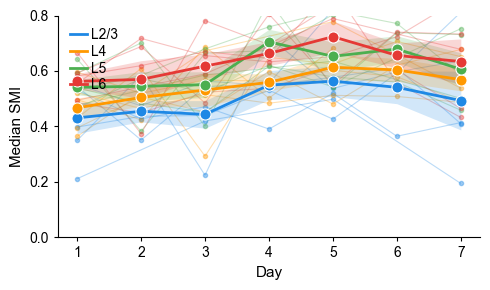

In [334]:
# Panel A â€” SMI development: mean Â± SEM of per-animal medians
# Individual animal values shown as small dots behind mean line

animal_medians = {l: {d: [] for d in all_days} for l in LAYER_ORDER}
# Also store which animal each value belongs to for per-animal traces
animal_median_by_id = {l: {animal: {} for animal in animals} for l in LAYER_ORDER}

for animal in animals:
    for day in all_days:
        if day not in smi_by_animal[animal]:
            continue
        for layer in LAYER_ORDER:
            if layer in smi_by_animal[animal][day]:
                med = np.median(smi_by_animal[animal][day][layer])
                animal_medians[layer][day].append(med)
                animal_median_by_id[layer][animal][day] = med

# â”€â”€ Plot â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig_a, ax = plt.subplots(figsize=(5, 3))

for layer in LAYER_ORDER:
    color = LAYER_COLORS[layer]

    # Individual animal traces (thin lines + small dots)
    for animal in animals:
        ad = animal_median_by_id[layer][animal]
        if not ad:
            continue
        axs = sorted(ad.keys())
        ays = [ad[d] for d in axs]
        ax.plot(axs, ays, color=color, lw=0.8, alpha=0.3, zorder=1)
        ax.scatter(axs, ays, color=color, s=3**2, alpha=0.4, zorder=2)

    # Mean Â± SEM across animals
    xs, ys, errs = [], [], []
    for day in all_days:
        vals = animal_medians[layer][day]
        if len(vals) < 2:
            continue
        xs.append(day)
        ys.append(np.mean(vals))
        errs.append(stats.sem(vals))

    xs   = np.array(xs)
    ys   = np.array(ys)
    errs = np.array(errs)

    ax.fill_between(xs, ys - errs, ys + errs, color=color, alpha=0.20, lw=0, zorder=3)
    ax.plot(xs, ys, color=color, lw=2, zorder=4, label=layer)
    ax.scatter(xs, ys, color=color, s=8**2, zorder=5,
               edgecolors='white', linewidths=0.8)

# â”€â”€ Axes â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ax.set_xlabel('Day', fontsize=11)
ax.set_ylabel('Median SMI', fontsize=11)
ax.set_xticks(all_days)
ax.set_xlim(all_days[0] - 0.3, all_days[-1] + 0.3)
ax.set_ylim(0.0, 0.8)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8])
ax.tick_params(axis='both', labelsize=10, length=3, width=0.8)

# ax.yaxis.grid(True, color='#CCCCCC', lw=0.6, zorder=0)
# ax.xaxis.grid(True, color='#CCCCCC', lw=0.6, zorder=0)
ax.set_axisbelow(True)

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(0.8)

ax.legend(fontsize=10, frameon=False, loc='upper left',
          handlelength=1.2, handletextpad=0.3, labelspacing=0.2)

plt.tight_layout()
for ext in ('.svg', '.png'):
    out = os.path.join(OUTPUT_DIR, f'figure3_panel_A_SMI_development{ext}')
    fig_a.savefig(out, dpi=300, bbox_inches='tight', format=ext.lstrip('.'))
    print(f'Saved: {out}')
plt.show()

Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\output\panel_B_SMI_heatmap.svg
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\output\panel_B_SMI_heatmap.png


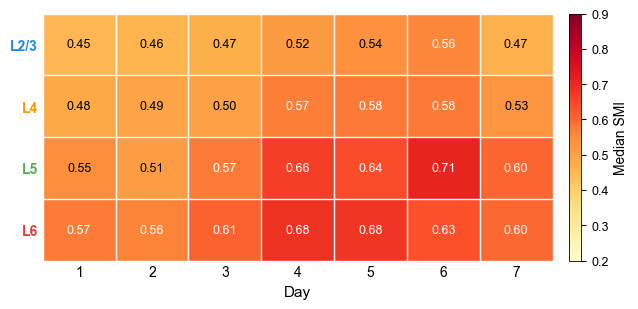

In [341]:
# Panel B — Median SMI by Layer × Day heatmap
# 4×7 matrix: pooled across all animals, overall median per cell

# Build 4×7 matrix: row=layer, col=day; pool all animals then take median
heatmap_matrix = np.full((len(LAYER_ORDER), len(all_days)), np.nan)
heatmap_annot  = [[''] * len(all_days) for _ in LAYER_ORDER]

for li, layer in enumerate(LAYER_ORDER):
    for di, day in enumerate(all_days):
        vals = []
        for animal in animals:
            if day in smi_by_animal[animal] and layer in smi_by_animal[animal][day]:
                vals.extend(smi_by_animal[animal][day][layer])
        if vals:
            med = np.median(vals)
            heatmap_matrix[li, di] = med
            heatmap_annot[li][di]  = f'{med:.2f}'

fig_b, ax = plt.subplots(figsize=(6.5, 3.2))

im = ax.imshow(heatmap_matrix, cmap='YlOrRd', vmin=0.2, vmax=0.9,
               aspect='auto', interpolation='nearest')

# Annotate cells
for li in range(len(LAYER_ORDER)):
    for di in range(len(all_days)):
        txt = heatmap_annot[li][di]
        if txt:
            val = heatmap_matrix[li, di]
            fc  = 'white' if val > 0.55 else 'black'
            ax.text(di, li, txt, ha='center', va='center',
                    fontsize=9, color=fc, fontfamily='Arial')

# Grid lines between cells
for x in np.arange(-0.5, len(all_days), 1):
    ax.axvline(x, color='white', lw=1.0)
for y in np.arange(-0.5, len(LAYER_ORDER), 1):
    ax.axhline(y, color='white', lw=1.0)

ax.set_xticks(range(len(all_days)))
ax.set_xticklabels([str(d) for d in all_days], fontsize=10)
ax.set_yticks(range(len(LAYER_ORDER)))
ax.set_yticklabels(LAYER_ORDER, fontsize=10)
for tick, layer in zip(ax.get_yticklabels(), LAYER_ORDER):
    tick.set_color(LAYER_COLORS[layer])
    tick.set_fontweight('bold')

ax.set_xlabel('Day', fontsize=11)
ax.tick_params(axis='both', length=0, width=0)

cbar = fig_b.colorbar(im, ax=ax, fraction=0.04, pad=0.03, aspect=20)
cbar.set_label('Median SMI', fontsize=10)
cbar.ax.tick_params(labelsize=9)
cbar.outline.set_linewidth(0.6)

ax.spines[:].set_visible(False)

plt.tight_layout()
for ext in ('.svg', '.png'):
    out = os.path.join(OUTPUT_DIR, f'panel_B_SMI_heatmap{ext}')
    fig_b.savefig(out, dpi=300, bbox_inches='tight', format=ext.lstrip('.'))
    print(f'Saved: {out}')
plt.show()

Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\output\figure3_panel_C_sup_vs_deep.svg
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\output\figure3_panel_C_sup_vs_deep.png


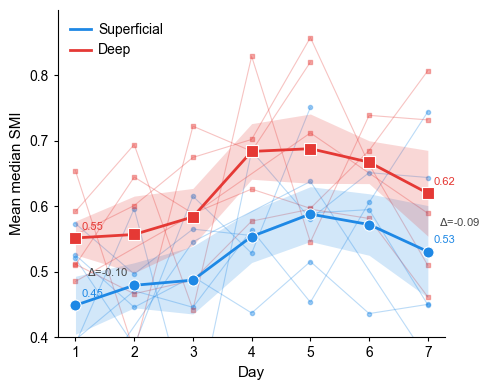

In [336]:
# Panel C â€” Superficial vs Deep two-line plot
# Per-animal daily values shown as small dots; mean Â± SEM as bold line

SUP_COLOR  = '#1E88E5'   # blue
DEEP_COLOR = '#E53935'   # red

sup_by_day   = {d: [] for d in all_days}   # list of per-animal values per day
deep_by_day  = {d: [] for d in all_days}
sup_by_animal  = {a: {} for a in animals}   # animal â†’ day â†’ value (for traces)
deep_by_animal = {a: {} for a in animals}

for animal in animals:
    for day in all_days:
        if day not in smi_by_animal[animal]:
            continue
        ad = smi_by_animal[animal][day]

        sup_meds  = [np.median(ad[l]) for l in ['L2/3', 'L4'] if l in ad]
        deep_meds = [np.median(ad[l]) for l in ['L5',  'L6']  if l in ad]

        if sup_meds:
            val = np.mean(sup_meds)
            sup_by_day[day].append(val)
            sup_by_animal[animal][day] = val
        if deep_meds:
            val = np.mean(deep_meds)
            deep_by_day[day].append(val)
            deep_by_animal[animal][day] = val

fig_c, ax = plt.subplots(figsize=(5, 4))

for label, color, by_day, by_animal_d, marker in [
    ('Superficial', SUP_COLOR,  sup_by_day,  sup_by_animal,  'o'),
    ('Deep',        DEEP_COLOR, deep_by_day, deep_by_animal, 's'),
]:
    # Individual animal traces
    for animal in animals:
        ad = by_animal_d[animal]
        if not ad:
            continue
        axs = sorted(ad.keys())
        ays = [ad[d] for d in axs]
        ax.plot(axs, ays, color=color, lw=0.8, alpha=0.3, zorder=1)
        ax.scatter(axs, ays, color=color, s=3**2, alpha=0.4, zorder=2, marker=marker)

    # Mean Â± SEM
    xs, ys, errs = [], [], []
    for day in all_days:
        vals = by_day[day]
        if len(vals) < 2:
            continue
        xs.append(day)
        ys.append(np.mean(vals))
        errs.append(stats.sem(vals))
    xs   = np.array(xs)
    ys   = np.array(ys)
    errs = np.array(errs)

    ax.fill_between(xs, ys - errs, ys + errs, color=color, alpha=0.20, lw=0, zorder=3)
    ax.plot(xs, ys, color=color, lw=2, zorder=4, label=label)
    ax.scatter(xs, ys, color=color, s=8**2, marker=marker, zorder=5,
               edgecolors='white', linewidths=0.8)

    # Annotate value at Day 1 and Day 7
    if len(xs) >= 2:
        for xi, yi in [(xs[0], ys[0]), (xs[-1], ys[-1])]:
            ax.annotate(f'{yi:.2f}', xy=(xi, yi),
                        xytext=(4, 6), textcoords='offset points',
                        fontsize=8, color=color, fontfamily='Arial')

# Annotate gap at Day 1 and Day 7
for day_val in [all_days[0], all_days[-1]]:
    s_vals = sup_by_day[day_val]
    d_vals = deep_by_day[day_val]
    if s_vals and d_vals:
        gap = np.mean(s_vals) - np.mean(d_vals)
        ax.annotate(f'$\Delta$={gap:.2f}',
                    xy=(day_val, (np.mean(s_vals) + np.mean(d_vals)) / 2),
                    xytext=(8, 0), textcoords='offset points',
                    fontsize=8, color='#444444', va='center', fontfamily='Arial')

ax.set_xlabel('Day', fontsize=11)
ax.set_ylabel('Mean median SMI', fontsize=11)
ax.set_xticks(all_days)
ax.set_xlim(all_days[0] - 0.3, all_days[-1] + 0.3)
ax.set_ylim(0.4, 0.9)
ax.set_yticks([0.4, 0.5, 0.6, 0.7, 0.8])
ax.tick_params(axis='both', labelsize=10, length=3, width=0.8)

# ax.yaxis.grid(True, color='#CCCCCC', lw=0.6, zorder=0)
# ax.xaxis.grid(True, color='#CCCCCC', lw=0.6, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(0.8)

ax.legend(fontsize=10, frameon=False, loc='upper left',
          handlelength=1.5, handletextpad=0.5)

plt.tight_layout()
for ext in ('.svg', '.png'):
    out = os.path.join(OUTPUT_DIR, f'figure3_panel_C_sup_vs_deep{ext}')
    fig_c.savefig(out, dpi=300, bbox_inches='tight', format=ext.lstrip('.'))
    print(f'Saved: {out}')
plt.show()

L2/3: early=0.434Â±0.032  late=0.506Â±0.027  p=3.125e-02  *
L4: early=0.470Â±0.023  late=0.571Â±0.018  p=3.125e-02  *
L5: early=0.517Â±0.021  late=0.616Â±0.024  p=3.125e-02  *
L6: early=0.542Â±0.020  late=0.607Â±0.026  p=3.125e-02  *
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\output\figure3_panel_D_early_vs_late.svg
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\output\figure3_panel_D_early_vs_late.png


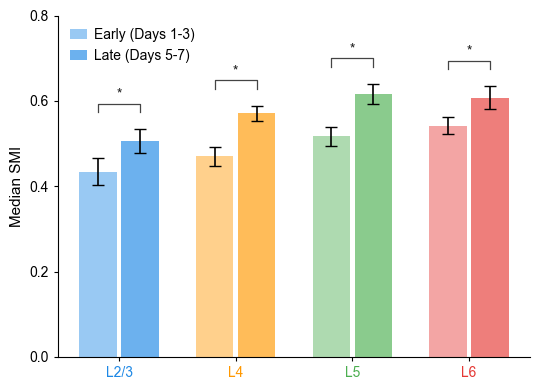

In [337]:
# Panel D â€” Early vs Late grouped bar chart
# Early = mean Days 1-3, Late = mean Days 5-7, per animal per layer

from scipy.stats import wilcoxon

EARLY_DAYS = [1, 2]
LATE_DAYS  = [5,6]

def sig_label(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

# Per-animal early/late medians
early_vals = {l: [] for l in LAYER_ORDER}
late_vals  = {l: [] for l in LAYER_ORDER}

for animal in animals:
    for layer in LAYER_ORDER:
        e_meds = []
        for day in EARLY_DAYS:
            if day in smi_by_animal[animal] and layer in smi_by_animal[animal][day]:
                e_meds.append(np.mean(smi_by_animal[animal][day][layer]))
        l_meds = []
        for day in LATE_DAYS:
            if day in smi_by_animal[animal] and layer in smi_by_animal[animal][day]:
                l_meds.append(np.mean(smi_by_animal[animal][day][layer]))

        if e_meds and l_meds:
            early_vals[layer].append(np.mean(e_meds))
            late_vals[layer].append(np.mean(l_meds))

# Statistics
stat_results = {}
for layer in LAYER_ORDER:
    ev = np.array(early_vals[layer])
    lv = np.array(late_vals[layer])
    if len(ev) >= 3 and len(lv) >= 3 and len(ev) == len(lv):
        try:
            _, p = wilcoxon(ev, lv)
        except Exception:
            _, p = stats.ttest_rel(ev, lv)
    else:
        p = np.nan
    stat_results[layer] = p
    print(f'{layer}: early={np.mean(ev):.3f}Â±{stats.sem(ev):.3f}  '
          f'late={np.mean(lv):.3f}Â±{stats.sem(lv):.3f}  p={p:.3e}  {sig_label(p)}')

# â”€â”€ Plot â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig_d, ax = plt.subplots(figsize=(5.5, 4))

x      = np.arange(len(LAYER_ORDER))
bw     = 0.32
offset = 0.18

for i, layer in enumerate(LAYER_ORDER):
    base_color = LAYER_COLORS[layer]
    ev = np.array(early_vals[layer])
    lv = np.array(late_vals[layer])

    # Early bar (light shade)
    ax.bar(x[i] - offset, np.mean(ev), width=bw,
           color=base_color, alpha=0.45, zorder=2,
           label='Early (Days 1-3)' if i == 0 else '')
    ax.errorbar(x[i] - offset, np.mean(ev), yerr=stats.sem(ev),
                fmt='none', color='black', capsize=4, lw=1.2, zorder=3)

    # Late bar (full shade)
    ax.bar(x[i] + offset, np.mean(lv), width=bw,
           color=base_color, alpha=0.65, zorder=2,
           label='Late (Days 5-7)' if i == 0 else '')
    ax.errorbar(x[i] + offset, np.mean(lv), yerr=stats.sem(lv),
                fmt='none', color='black', capsize=4, lw=1.2, zorder=3)

    # Significance bracket
    p   = stat_results[layer]
    lbl = sig_label(p)
    if not np.isnan(p):
        bar_top   = max(np.mean(ev) + stats.sem(ev),
                        np.mean(lv) + stats.sem(lv)) + 0.04
        bracket_h = 0.02
        ax.plot([x[i] - offset, x[i] - offset,
                 x[i] + offset, x[i] + offset],
                [bar_top, bar_top + bracket_h,
                 bar_top + bracket_h, bar_top],
                color='#444444', lw=0.9, zorder=5)
        ax.text(x[i], bar_top + bracket_h + 0.005, lbl,
                ha='center', va='bottom', fontsize=10,
                fontfamily='Arial', color='#222222')

ax.set_xticks(x)
ax.set_xticklabels(LAYER_ORDER, fontsize=12)
for tick, layer in zip(ax.get_xticklabels(), LAYER_ORDER):
    tick.set_color(LAYER_COLORS[layer])

ax.set_ylabel('Median SMI', fontsize=11)
ax.set_ylim(0.0, 0.8)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8])
ax.tick_params(axis='both', labelsize=10, length=3, width=0.8)

# ax.yaxis.grid(True, color='#CCCCCC', lw=0.6, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(0.8)

ax.legend(fontsize=10, frameon=False, loc='upper left',
          handlelength=1.2, handletextpad=0.5)

plt.tight_layout()
for ext in ('.svg', '.png'):
    out = os.path.join(OUTPUT_DIR, f'figure3_panel_D_early_vs_late{ext}')
    fig_d.savefig(out, dpi=300, bbox_inches='tight', format=ext.lstrip('.'))
    print(f'Saved: {out}')
plt.show()

Gain scores (Day 7 - Day 1):
  L2/3: n=6  mean gain=0.133±0.060  p=9.375e-02  ns
  L4: n=6  mean gain=0.135±0.047  p=6.250e-02  ns
  L5: n=6  mean gain=0.120±0.041  p=3.125e-02  *
  L6: n=6  mean gain=0.137±0.048  p=3.125e-02  *
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\output\panel_E_SMI_gain.svg
Saved: c:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation\Poster\output\panel_E_SMI_gain.png


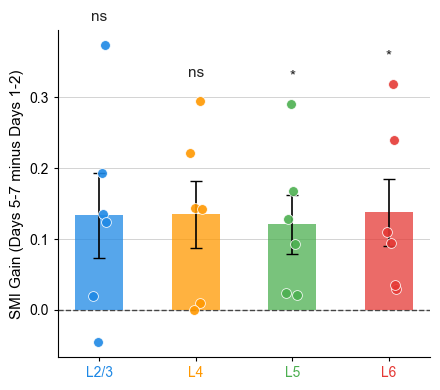

In [338]:
# Panel E — SMI Gain Score bar plot (Day 7 - Day 1) per layer
# Gain = per-animal median SMI Day 7 minus Day 1
# Bar = mean gain ± SEM; individual animal dots overlaid; dashed zero line

from scipy.stats import wilcoxon, ttest_1samp

def sig_label(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

# Collect gain per animal per layer
gain_data = {l: {"gains": [], "animals": []} for l in LAYER_ORDER}

for animal in animals:
    for layer in LAYER_ORDER:
        EARLY_DAYS = [1, 2]
        LATE_DAYS  = [5, 6, 7]
        early_meds = [np.median(smi_by_animal[animal][d][layer])
                      for d in EARLY_DAYS
                      if d in smi_by_animal[animal] and layer in smi_by_animal[animal][d]]
        late_meds  = [np.median(smi_by_animal[animal][d][layer])
                      for d in LATE_DAYS
                      if d in smi_by_animal[animal] and layer in smi_by_animal[animal][d]]
        if early_meds and late_meds:
            gain = np.mean(late_meds) - np.mean(early_meds)
            gain_data[layer]["gains"].append(gain)
            gain_data[layer]["animals"].append(animal)

print("Gain scores (Day 7 - Day 1):")
for layer in LAYER_ORDER:
    g = np.array(gain_data[layer]["gains"])
    n = len(g)
    if n >= 2:
        try:
            _, p = wilcoxon(g)
        except Exception:
            _, p = ttest_1samp(g, 0)
    else:
        p = np.nan
    gain_data[layer]["p"] = p
    mean_g = np.mean(g) if n > 0 else np.nan
    sem_g  = stats.sem(g) if n > 1 else np.nan
    print(f"  {layer}: n={n}  mean gain={mean_g:.3f}±{sem_g:.3f}  p={p:.3e}  {sig_label(p)}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig_e, ax = plt.subplots(figsize=(4.5, 4))

x = np.arange(len(LAYER_ORDER))
bw = 0.5
rng = np.random.default_rng(42)

for i, layer in enumerate(LAYER_ORDER):
    color = LAYER_COLORS[layer]
    g = np.array(gain_data[layer]["gains"])
    n = len(g)
    if n == 0:
        continue

    mean_g = np.mean(g)
    sem_g  = stats.sem(g) if n > 1 else 0.0

    # Bar
    ax.bar(x[i], mean_g, width=bw, color=color, alpha=0.75, zorder=2)
    ax.errorbar(x[i], mean_g, yerr=sem_g,
                fmt="none", color="black", capsize=4, lw=1.2, zorder=3)

    # Individual dots (jittered)
    jitter = rng.uniform(-0.08, 0.08, size=n)
    ax.scatter(x[i] + jitter, g, color=color, s=50, alpha=0.9,
               edgecolors="white", linewidths=0.6, zorder=4)

    # Significance vs zero
    p = gain_data[layer]["p"]
    lbl = sig_label(p)
    if not np.isnan(p):
        y_top = max(mean_g + sem_g, np.max(g)) + 0.03
        ax.text(x[i], y_top, lbl, ha="center", va="bottom",
                fontsize=11, fontfamily="Arial", color="#222222")

# Zero reference line
ax.axhline(0, color="#444444", lw=1.0, ls="--", zorder=1)

ax.set_xticks(x)
ax.set_xticklabels(LAYER_ORDER, fontsize=12)
for tick, layer in zip(ax.get_xticklabels(), LAYER_ORDER):
    tick.set_color(LAYER_COLORS[layer])

ax.set_ylabel("SMI Gain (Days 5-7 minus Days 1-2)", fontsize=11)
ax.tick_params(axis="both", labelsize=10, length=3, width=0.8)

ax.yaxis.grid(True, color="#CCCCCC", lw=0.6, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_linewidth(0.8)

plt.tight_layout()
for ext in (".svg", ".png"):
    out = os.path.join(OUTPUT_DIR, f"panel_E_SMI_gain{ext}")
    fig_e.savefig(out, dpi=300, bbox_inches="tight", format=ext.lstrip("."))
    print(f"Saved: {out}")
plt.show()
